In [1]:
import joblib              as jlb
import matplotlib.pyplot   as plt
import warnings
warnings.filterwarnings('ignore')
    
from collections           import Counter
from Algorithm             import PAM
from pyclustering.utils import timedcall
from Dataprepare.data_processing import D,data_pca

Tiền xử lý dữ liệu

In [2]:
features=[
 'balance',
 'purchases',
 'cash_advance'
]
data=D[features].copy()
print(data.head(2))

    balance  purchases  cash_advance
0 -1.334707  -0.123312     -0.937894
1  0.952729  -1.686451      1.518315


Xây dựng mô hình PAM

In [3]:
k=3
Pam_model=PAM(data,n_clusters = k)
(ticks,results) = timedcall(Pam_model.fit)
print(f'PAM clustering completed in {ticks:.4f} seconds.')

PAM clustering completed in 0.6914 seconds.


In [4]:
## Lưu trữ mô hình để khai thác về sau
jlb.dump(Pam_model, '../customer_clustering/Output/PAM.mdl')

['../customer_clustering/Output/PAM.mdl']

In [5]:
## Khai thác mô hình đã được xây dựng
saved=jlb.load('../customer_clustering/Output/PAM.mdl')

In [6]:
## Kết quả gom cụm khách hàng
data['cluster'] = saved.get_labels()

print('\nKích thước các clusters:', Counter(data['cluster']))
print('\n2 clusters lớn nhất:',    Counter(data['cluster']).most_common(2))


Kích thước các clusters: Counter({1: 4540, 2: 2054, 0: 2042})

2 clusters lớn nhất: [(1, 4540), (2, 2054)]


In [7]:
medoids = saved.get_medoids()
labels= saved.get_labels()
print(labels)
print(medoids)

[1 0 1 ... 1 0 1]
[[ 0.52892167 -1.68645076  1.04568361]
 [-0.47352069  0.61807349 -0.93789448]
 [ 0.72077747  0.45278328  1.0608887 ]]


Biểu diễn trực quan

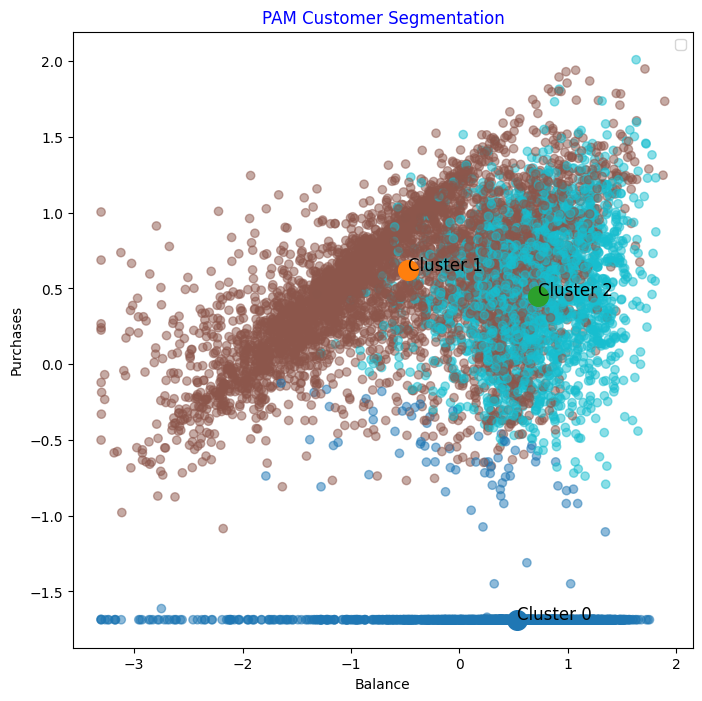

In [8]:
plt.figure(figsize = (8, 8))
plt.scatter(data['balance'], data['purchases'], c = labels, alpha = 0.5, cmap = 'tab10')
for i, medoid in enumerate(medoids):
    plt.scatter(medoid[0], medoid[1], s=200, marker='o')

    plt.text(
        medoid[0],
        medoid[1],
        f'Cluster {i}',
        fontsize=12
    )
plt.xlabel('Balance')
plt.ylabel('Purchases')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()

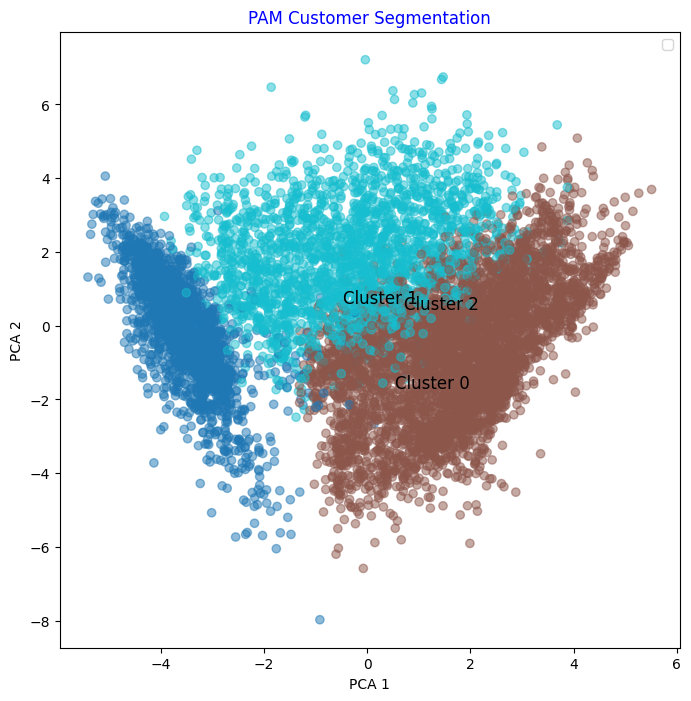

In [10]:
plt.figure(figsize = (8, 8))
plt.scatter(data_pca[:, 0], data_pca[:, 1], c = labels, alpha = 0.5, cmap = 'tab10')
for i, medoid in enumerate(medoids):

    plt.text(
        medoid[0],
        medoid[1],
        f'Cluster {i}',
        fontsize=12
    )
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('PAM Customer Segmentation', color = 'blue')
plt.legend()
plt.show()